# EDA 05 - Revenue Month, Quarter, and Year Seasonality

This notebook analyzes revenue seasonality using `sales.csv`, focusing on repeated monthly, quarterly, and yearly calendar patterns useful for forecasting, inventory planning, and marketing timing.

## 1. Setup and file discovery

Locate `sales.csv` recursively from the current working directory and configure common analysis settings.

In [ ]:
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 160)

PROJECT_ROOT = Path.cwd()
SALES_FILENAME = "sales.csv"
MONTH_NAMES = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
QUARTER_LABELS = ["Q1", "Q2", "Q3", "Q4"]

sales_matches = sorted(PROJECT_ROOT.rglob(SALES_FILENAME), key=lambda p: (len(p.parts), str(p)))
sales_path = sales_matches[0] if sales_matches else None

file_discovery_df = pd.DataFrame([{
    "file": SALES_FILENAME,
    "found": sales_path is not None,
    "path": str(sales_path.relative_to(PROJECT_ROOT)) if sales_path else None,
    "match_count": len(sales_matches),
}])

print(f"Project root: {PROJECT_ROOT}")
file_discovery_df

Project root: D:\Code\Datathon 2026


,file,found,path,match_count
0,sales.csv,True,datathon-2026-round-1\sales.csv,1


## 2. Load sales data

Load the sales file safely. If loading fails, the notebook displays warnings and avoids crashing.

In [2]:
sales_raw = None
load_error = None

if sales_path is None:
    load_error = "sales.csv was not found."
else:
    try:
        sales_raw = pd.read_csv(sales_path, low_memory=False)
    except Exception as exc:
        load_error = repr(exc)

if sales_raw is None:
    load_summary_df = pd.DataFrame([{"file": SALES_FILENAME, "loaded": False, "rows": np.nan, "columns": np.nan, "error": load_error}])
else:
    load_summary_df = pd.DataFrame([{"file": SALES_FILENAME, "loaded": True, "rows": len(sales_raw), "columns": len(sales_raw.columns), "error": ""}])

display(load_summary_df)
if sales_raw is not None:
    display(sales_raw.head())

,file,loaded,rows,columns,error
0,sales.csv,True,3833,3,


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


## 3. Identify date and revenue columns

Detect the most likely date and revenue columns using normalized column names, datetime parse success, and numeric parse success.

In [3]:
def normalize_name(name):
    return re.sub(r"[^a-z0-9]+", "_", str(name).strip().lower()).strip("_")


def numeric_series(series):
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce")
    cleaned = series.astype("string").str.strip().str.replace(",", "", regex=False)
    return pd.to_numeric(cleaned, errors="coerce")


def date_score(column_name, series):
    name = normalize_name(column_name)
    name_points = 0
    if name in {"date", "sales_date", "order_date"}:
        name_points += 3
    elif "date" in name or "time" in name or "timestamp" in name:
        name_points += 2
    parsed = pd.to_datetime(series, errors="coerce")
    non_null = series.notna().sum()
    success = parsed.notna().sum() / non_null if non_null else 0
    return name_points + success, success, parsed


def revenue_score(column_name, series):
    name = normalize_name(column_name)
    name_points = 0
    if name == "revenue":
        name_points += 5
    elif "revenue" in name or "sales" in name or "amount" in name:
        name_points += 3
    numeric = numeric_series(series)
    non_null = series.notna().sum()
    success = numeric.notna().sum() / non_null if non_null else 0
    positive_share = (numeric.dropna() > 0).mean() if numeric.notna().sum() else 0
    variability = numeric.std(skipna=True) if numeric.notna().sum() else 0
    return name_points + success + positive_share + (1 if variability and variability > 0 else 0), success, numeric

if sales_raw is None:
    date_col = None
    revenue_col = None
    parsed_date = None
    parsed_revenue = None
    column_detection_df = pd.DataFrame([{"warning": "sales.csv not loaded"}])
else:
    date_candidates = []
    revenue_candidates = []
    for col in sales_raw.columns:
        d_score, d_success, _ = date_score(col, sales_raw[col])
        r_score, r_success, _ = revenue_score(col, sales_raw[col])
        date_candidates.append({"column": col, "date_score": d_score, "date_parse_success": d_success})
        revenue_candidates.append({"column": col, "revenue_score": r_score, "numeric_parse_success": r_success})
    date_candidates_df = pd.DataFrame(date_candidates).sort_values("date_score", ascending=False)
    revenue_candidates_df = pd.DataFrame(revenue_candidates).sort_values("revenue_score", ascending=False)
    date_col = date_candidates_df.iloc[0]["column"] if len(date_candidates_df) and date_candidates_df.iloc[0]["date_parse_success"] > 0.5 else None
    revenue_col = revenue_candidates_df.iloc[0]["column"] if len(revenue_candidates_df) and revenue_candidates_df.iloc[0]["numeric_parse_success"] > 0.8 else None
    parsed_date = pd.to_datetime(sales_raw[date_col], errors="coerce") if date_col else None
    parsed_revenue = numeric_series(sales_raw[revenue_col]) if revenue_col else None
    column_detection_df = pd.DataFrame([{
        "selected_date_column": date_col,
        "selected_revenue_column": revenue_col,
        "date_parse_success": parsed_date.notna().mean() if parsed_date is not None else np.nan,
        "revenue_numeric_success": parsed_revenue.notna().mean() if parsed_revenue is not None else np.nan,
    }])

print("Selected columns")
display(column_detection_df)
if sales_raw is not None:
    print("Date candidates")
    display(date_candidates_df)
    print("Revenue candidates")
    display(revenue_candidates_df)

Selected columns


,selected_date_column,selected_revenue_column,date_parse_success,revenue_numeric_success
0,Date,Revenue,1.0,1.0


Date candidates


,column,date_score,date_parse_success
0,Date,4.0,1.0
1,Revenue,1.0,1.0
2,COGS,1.0,1.0


Revenue candidates


,column,revenue_score,numeric_parse_success
1,Revenue,8.0,1.0
2,COGS,3.0,1.0
0,Date,0.0,0.0


## 4. Prepare calendar fields

Parse the date and revenue fields, aggregate to daily revenue if needed, fill only calendar metadata, and create month, quarter, week, and day-of-year fields.

In [4]:
analysis_ready = sales_raw is not None and date_col is not None and revenue_col is not None

if not analysis_ready:
    print("WARNING: A usable date or revenue column was not found. Analysis sections will be skipped safely.")
    daily = pd.DataFrame(columns=["date", "revenue"])
else:
    prepared = pd.DataFrame({"date": parsed_date, "revenue": parsed_revenue})
    prepared = prepared.dropna(subset=["date", "revenue"])
    prepared["date"] = prepared["date"].dt.normalize()
    duplicate_dates_before_aggregation = int(prepared.duplicated(subset=["date"]).sum())
    daily = prepared.groupby("date", as_index=False)["revenue"].sum().sort_values("date").reset_index(drop=True)
    full_index = pd.date_range(daily["date"].min(), daily["date"].max(), freq="D")
    missing_dates = full_index.difference(pd.DatetimeIndex(daily["date"]))

    daily["year"] = daily["date"].dt.year
    daily["quarter"] = daily["date"].dt.quarter
    daily["month"] = daily["date"].dt.month
    daily["month_name"] = daily["date"].dt.month_name().str[:3]
    daily["weekofyear"] = daily["date"].dt.isocalendar().week.astype(int)
    daily["dayofyear"] = daily["date"].dt.dayofyear
    daily["year_month"] = daily["date"].dt.to_period("M").astype(str)

    prep_summary_df = pd.DataFrame([{
        "date_column": date_col,
        "revenue_column": revenue_col,
        "raw_rows": len(sales_raw),
        "daily_rows": len(daily),
        "duplicate_dates_before_aggregation": duplicate_dates_before_aggregation,
        "min_date": daily["date"].min(),
        "max_date": daily["date"].max(),
        "missing_daily_dates": len(missing_dates),
        "first_20_missing_dates": [d.strftime("%Y-%m-%d") for d in missing_dates[:20]],
    }])
    display(prep_summary_df)
    display(daily.head())

,date_column,revenue_column,raw_rows,daily_rows,duplicate_dates_before_aggregation,min_date,max_date,missing_daily_dates,first_20_missing_dates
0,Date,Revenue,3833,3833,0,2012-07-04,2022-12-31,0,[]


,date,revenue,year,quarter,month,month_name,weekofyear,dayofyear,year_month
0,2012-07-04,5123547.94,2012,3,7,Jul,27,186,2012-07
1,2012-07-05,2751773.45,2012,3,7,Jul,27,187,2012-07
2,2012-07-06,3054029.42,2012,3,7,Jul,27,188,2012-07
3,2012-07-07,2667930.94,2012,3,7,Jul,27,189,2012-07
4,2012-07-08,2360851.90,2012,3,7,Jul,27,190,2012-07


## 5. Revenue by month

Aggregate revenue by month of year across the full dataset, identify top/bottom months, and plot both average revenue and distribution by month.

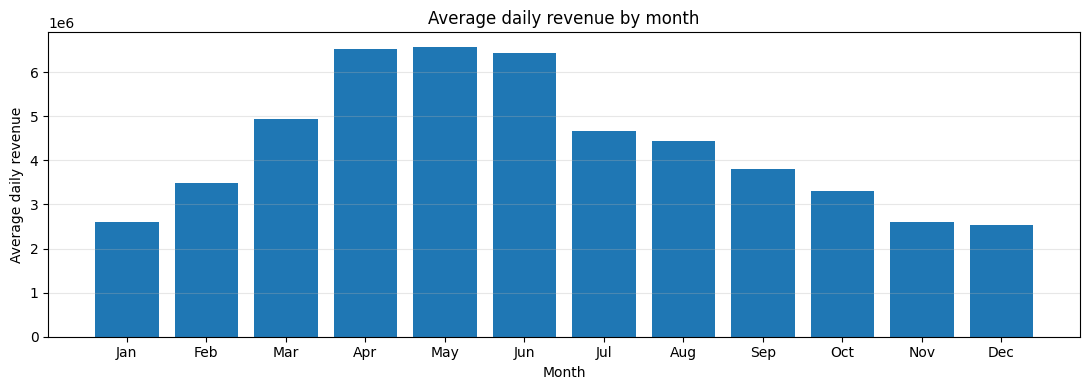

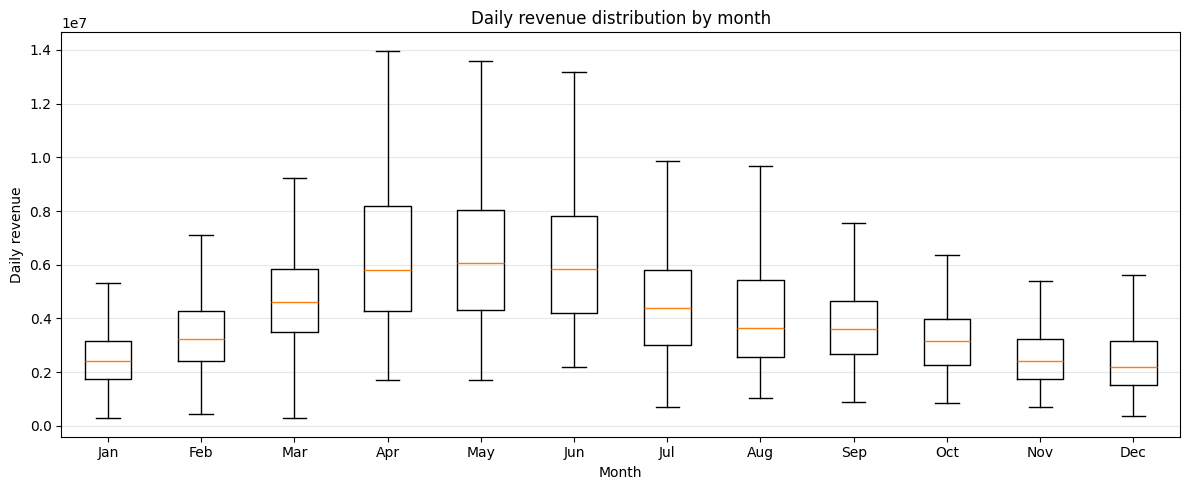

Revenue by month


,month,month_name,total_revenue,average_daily_revenue,median_daily_revenue,std_daily_revenue,observation_count
0,1,Jan,8.032579e+08,2.591155e+06,2416732.695,1.227779e+06,310
1,2,Feb,9.815858e+08,3.480801e+06,3242762.870,1.548857e+06,282
2,3,Mar,1.527737e+09,4.928185e+06,4606234.990,2.570799e+06,310
3,4,Apr,1.959886e+09,6.532952e+06,5795217.085,3.141239e+06,300
4,5,May,2.038379e+09,6.575416e+06,6067768.610,3.097940e+06,310
5,6,Jun,1.928133e+09,6.427109e+06,5826463.100,2.954491e+06,300
6,7,Jul,1.575009e+09,4.659789e+06,4379419.245,2.140904e+06,338
7,8,Aug,1.514447e+09,4.441193e+06,3646382.120,2.641334e+06,341
8,9,Sep,1.253282e+09,3.797826e+06,3604251.200,1.595662e+06,330
9,10,Oct,1.126229e+09,3.302725e+06,3172297.010,1.346819e+06,341


Top revenue months by average daily revenue


,month,month_name,total_revenue,average_daily_revenue,median_daily_revenue,std_daily_revenue,observation_count
4,5,May,2.038379e+09,6.575416e+06,6067768.610,3.097940e+06,310
3,4,Apr,1.959886e+09,6.532952e+06,5795217.085,3.141239e+06,300
5,6,Jun,1.928133e+09,6.427109e+06,5826463.100,2.954491e+06,300
2,3,Mar,1.527737e+09,4.928185e+06,4606234.990,2.570799e+06,310
6,7,Jul,1.575009e+09,4.659789e+06,4379419.245,2.140904e+06,338


Bottom revenue months by average daily revenue


,month,month_name,total_revenue,average_daily_revenue,median_daily_revenue,std_daily_revenue,observation_count
11,12,Dec,8.608032e+08,2.524350e+06,2201374.590,1.482438e+06,341
0,1,Jan,8.032579e+08,2.591155e+06,2416732.695,1.227779e+06,310
10,11,Nov,8.617274e+08,2.611295e+06,2419587.955,1.118930e+06,330
9,10,Oct,1.126229e+09,3.302725e+06,3172297.010,1.346819e+06,341
1,2,Feb,9.815858e+08,3.480801e+06,3242762.870,1.548857e+06,282


In [5]:
if daily.empty:
    print("Revenue by month skipped because daily series is unavailable.")
    month_summary_df = pd.DataFrame()
else:
    month_summary_df = daily.groupby("month").agg(
        total_revenue=("revenue", "sum"),
        average_daily_revenue=("revenue", "mean"),
        median_daily_revenue=("revenue", "median"),
        std_daily_revenue=("revenue", "std"),
        observation_count=("revenue", "size"),
    ).reset_index()
    month_summary_df["month_name"] = month_summary_df["month"].map(dict(enumerate(MONTH_NAMES, start=1)))
    month_summary_df = month_summary_df[["month", "month_name", "total_revenue", "average_daily_revenue", "median_daily_revenue", "std_daily_revenue", "observation_count"]]

    top_months_df = month_summary_df.sort_values("average_daily_revenue", ascending=False).head(5)
    bottom_months_df = month_summary_df.sort_values("average_daily_revenue", ascending=True).head(5)

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.bar(month_summary_df["month_name"], month_summary_df["average_daily_revenue"])
    ax.set_title("Average daily revenue by month")
    ax.set_xlabel("Month")
    ax.set_ylabel("Average daily revenue")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    month_data = [daily.loc[daily["month"] == m, "revenue"].values for m in range(1, 13)]
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.boxplot(month_data, labels=MONTH_NAMES, showfliers=False)
    ax.set_title("Daily revenue distribution by month")
    ax.set_xlabel("Month")
    ax.set_ylabel("Daily revenue")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("Revenue by month")
    display(month_summary_df)
    print("Top revenue months by average daily revenue")
    display(top_months_df)
    print("Bottom revenue months by average daily revenue")
    display(bottom_months_df)

## 6. Revenue by quarter

Aggregate revenue by quarter and assess peak and low quarters.

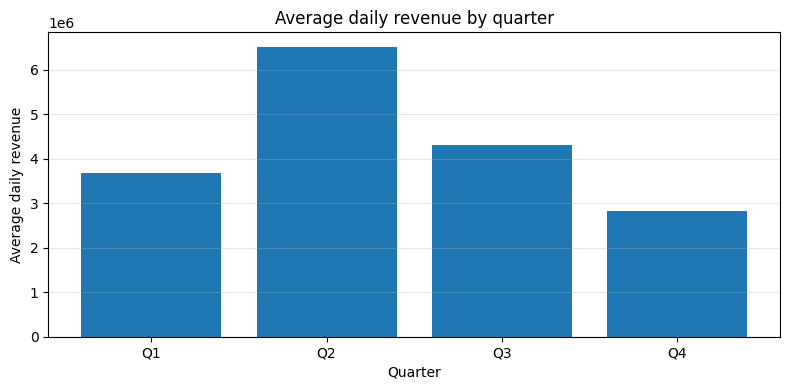

Revenue by quarter


,quarter,quarter_label,total_revenue,average_daily_revenue,median_daily_revenue,std_daily_revenue,observation_count
0,1,Q1,3.312581e+09,3.672485e+06,3274872.865,2.118501e+06,902
1,2,Q2,5.926397e+09,6.512524e+06,5903544.270,3.063215e+06,910
2,3,Q3,4.342738e+09,4.304002e+06,3855254.640,2.202119e+06,1009
3,4,Q4,2.848760e+09,2.814980e+06,2587818.655,1.370687e+06,1012


Quarter ranking by average daily revenue


,quarter,quarter_label,total_revenue,average_daily_revenue,median_daily_revenue,std_daily_revenue,observation_count
1,2,Q2,5.926397e+09,6.512524e+06,5903544.270,3.063215e+06,910
2,3,Q3,4.342738e+09,4.304002e+06,3855254.640,2.202119e+06,1009
0,1,Q1,3.312581e+09,3.672485e+06,3274872.865,2.118501e+06,902
3,4,Q4,2.848760e+09,2.814980e+06,2587818.655,1.370687e+06,1012


In [6]:
if daily.empty:
    print("Revenue by quarter skipped because daily series is unavailable.")
    quarter_summary_df = pd.DataFrame()
else:
    quarter_summary_df = daily.groupby("quarter").agg(
        total_revenue=("revenue", "sum"),
        average_daily_revenue=("revenue", "mean"),
        median_daily_revenue=("revenue", "median"),
        std_daily_revenue=("revenue", "std"),
        observation_count=("revenue", "size"),
    ).reset_index()
    quarter_summary_df["quarter_label"] = "Q" + quarter_summary_df["quarter"].astype(str)
    quarter_summary_df = quarter_summary_df[["quarter", "quarter_label", "total_revenue", "average_daily_revenue", "median_daily_revenue", "std_daily_revenue", "observation_count"]]
    peak_quarters_df = quarter_summary_df.sort_values("average_daily_revenue", ascending=False)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(quarter_summary_df["quarter_label"], quarter_summary_df["average_daily_revenue"])
    ax.set_title("Average daily revenue by quarter")
    ax.set_xlabel("Quarter")
    ax.set_ylabel("Average daily revenue")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("Revenue by quarter")
    display(quarter_summary_df)
    print("Quarter ranking by average daily revenue")
    display(peak_quarters_df)

## 7. Revenue by year

Aggregate revenue by year, calculate year-over-year growth, and compare monthly seasonality across years.

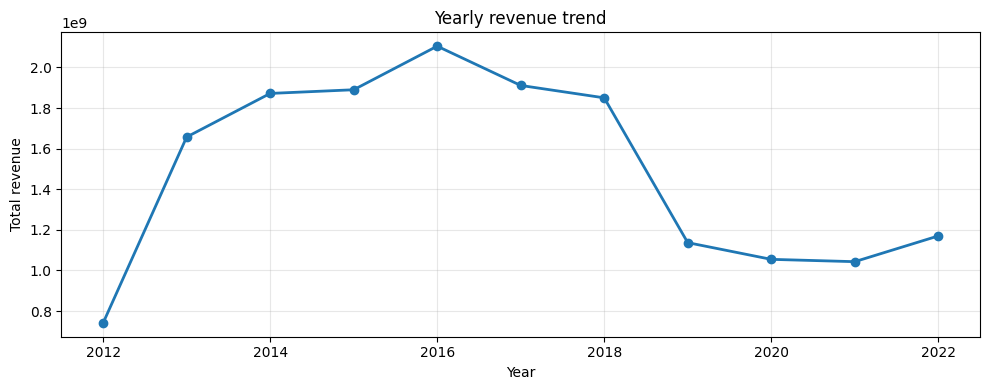

Revenue by year


,year,total_revenue,average_daily_revenue,days_observed,average_monthly_revenue,yoy_revenue_growth_pct
0,2012,7.414977e+08,4.096673e+06,181,1.235830e+08,NaN
1,2013,1.657169e+09,4.540190e+06,365,1.380975e+08,123.489474
2,2014,1.871846e+09,5.128345e+06,365,1.559872e+08,12.954407
3,2015,1.889934e+09,5.177901e+06,365,1.574945e+08,0.966316
4,2016,2.104641e+09,5.750384e+06,366,1.753867e+08,11.360549
5,2017,1.911164e+09,5.236067e+06,365,1.592637e+08,-9.192845
6,2018,1.850122e+09,5.068829e+06,365,1.541769e+08,-3.193962
7,2019,1.136801e+09,3.114524e+06,365,9.473345e+07,-38.555341
8,2020,1.054512e+09,2.881181e+06,366,8.787601e+07,-7.238668
9,2021,1.043040e+09,2.857643e+06,365,8.691998e+07,-1.087929


Year/month revenue ranks


,year,month,revenue,rank_within_year
0,2012,7,1.304068e+08,2.0
1,2012,8,1.590892e+08,1.0
2,2012,9,1.293071e+08,3.0
3,2012,10,1.101857e+08,5.0
4,2012,11,9.818630e+07,6.0
5,2012,12,1.143226e+08,4.0
6,2013,1,9.130868e+07,10.0
7,2013,2,1.097831e+08,9.0
8,2013,3,1.518347e+08,5.0
9,2013,4,1.989269e+08,2.0


In [7]:
if daily.empty:
    print("Revenue by year skipped because daily series is unavailable.")
    yearly_summary_df = pd.DataFrame()
else:
    monthly_by_year = daily.groupby(["year", "month"], as_index=False)["revenue"].sum()
    yearly_summary_df = daily.groupby("year").agg(
        total_revenue=("revenue", "sum"),
        average_daily_revenue=("revenue", "mean"),
        days_observed=("revenue", "size"),
    ).reset_index()
    avg_monthly = monthly_by_year.groupby("year")["revenue"].mean().rename("average_monthly_revenue")
    yearly_summary_df = yearly_summary_df.merge(avg_monthly, on="year", how="left")
    yearly_summary_df["yoy_revenue_growth_pct"] = yearly_summary_df["total_revenue"].pct_change() * 100

    yearly_month_rank_df = monthly_by_year.copy()
    yearly_month_rank_df["rank_within_year"] = yearly_month_rank_df.groupby("year")["revenue"].rank(ascending=False, method="min")

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(yearly_summary_df["year"], yearly_summary_df["total_revenue"], marker="o", linewidth=2)
    ax.set_title("Yearly revenue trend")
    ax.set_xlabel("Year")
    ax.set_ylabel("Total revenue")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("Revenue by year")
    display(yearly_summary_df)
    print("Year/month revenue ranks")
    display(yearly_month_rank_df)

## 8. Year ? month heatmap

Create a year-by-month matrix of monthly revenue and visualize it with a matplotlib heatmap-style chart.

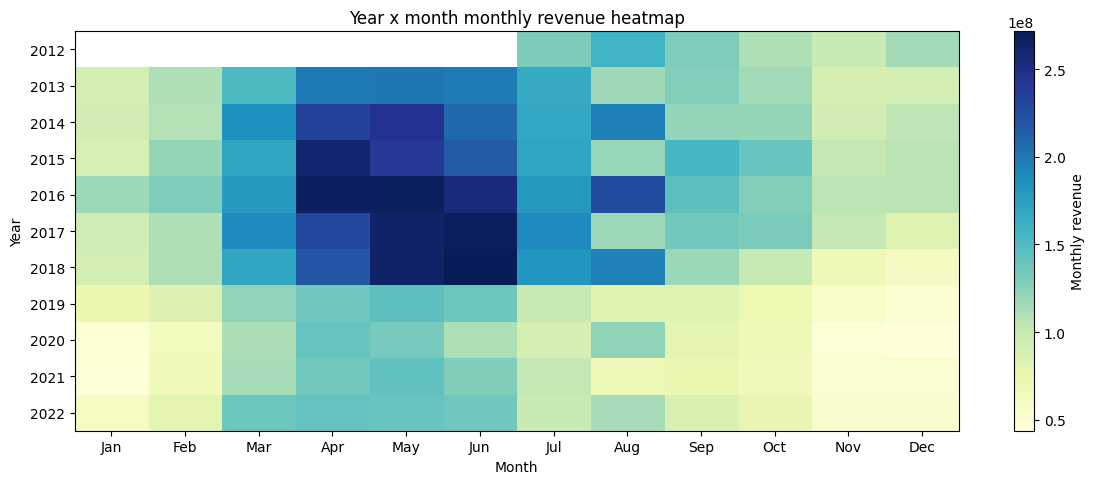

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
year,,,,,,,,,,,,
2012,NaN,NaN,NaN,NaN,NaN,NaN,1.304068e+08,1.590892e+08,1.293071e+08,1.101857e+08,9.818630e+07,1.143226e+08
2013,9.130868e+07,1.097831e+08,1.518347e+08,1.989269e+08,2.005001e+08,1.985176e+08,1.657454e+08,1.162718e+08,1.275341e+08,1.150898e+08,9.037131e+07,9.128587e+07
2014,9.180371e+07,1.084410e+08,1.835139e+08,2.325656e+08,2.443095e+08,2.081338e+08,1.691579e+08,1.952658e+08,1.206215e+08,1.209828e+08,9.329358e+07,1.037567e+08
2015,8.988064e+07,1.206825e+08,1.709403e+08,2.596944e+08,2.403847e+08,2.158364e+08,1.702370e+08,1.198550e+08,1.550307e+08,1.392310e+08,1.023118e+08,1.058494e+08
2016,1.172047e+08,1.296951e+08,1.791458e+08,2.671138e+08,2.681319e+08,2.539394e+08,1.791667e+08,2.270085e+08,1.451531e+08,1.273506e+08,1.051141e+08,1.056170e+08
2017,9.527163e+07,1.099839e+08,1.883824e+08,2.295269e+08,2.629088e+08,2.674333e+08,1.889944e+08,1.172974e+08,1.349440e+08,1.317229e+08,1.009589e+08,8.373978e+07
2018,9.096351e+07,1.103128e+08,1.700950e+08,2.202236e+08,2.627785e+08,2.716742e+08,1.820708e+08,1.942757e+08,1.179692e+08,1.005856e+08,6.790365e+07,6.126989e+07
2019,7.296021e+07,8.505806e+07,1.212090e+08,1.357313e+08,1.444431e+08,1.377309e+08,9.938487e+07,8.149559e+07,8.329073e+07,7.205786e+07,5.500828e+07,4.843156e+07
2020,4.772826e+07,6.244869e+07,1.118044e+08,1.399607e+08,1.328238e+08,1.106050e+08,9.070164e+07,1.220650e+08,7.882581e+07,6.813646e+07,4.574088e+07,4.367156e+07


In [8]:
if daily.empty:
    print("Year x month heatmap skipped because daily series is unavailable.")
    year_month_matrix = pd.DataFrame()
else:
    monthly_revenue = daily.groupby(["year", "month"], as_index=False)["revenue"].sum()
    year_month_matrix = monthly_revenue.pivot(index="year", columns="month", values="revenue").reindex(columns=range(1, 13))
    year_month_matrix.columns = MONTH_NAMES

    fig, ax = plt.subplots(figsize=(12, max(4, 0.45 * len(year_month_matrix))))
    im = ax.imshow(year_month_matrix.values, aspect="auto", cmap="YlGnBu")
    ax.set_xticks(np.arange(12))
    ax.set_xticklabels(MONTH_NAMES)
    ax.set_yticks(np.arange(len(year_month_matrix.index)))
    ax.set_yticklabels(year_month_matrix.index)
    ax.set_title("Year x month monthly revenue heatmap")
    ax.set_xlabel("Month")
    ax.set_ylabel("Year")
    fig.colorbar(im, ax=ax, label="Monthly revenue")
    plt.tight_layout()
    plt.show()

    display(year_month_matrix)

## 9. Seasonal subseries plot

Plot each year across months to assess whether monthly patterns repeat across years.

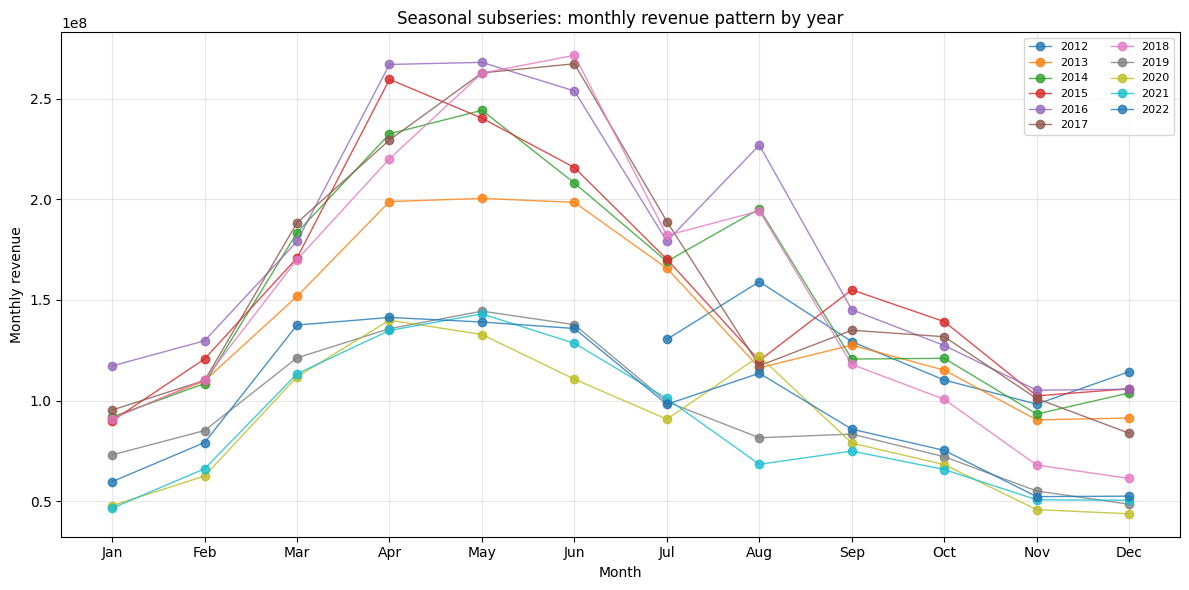

In [9]:
if daily.empty:
    print("Seasonal subseries plot skipped because daily series is unavailable.")
else:
    fig, ax = plt.subplots(figsize=(12, 6))
    for year in sorted(monthly_revenue["year"].unique()):
        year_data = monthly_revenue[monthly_revenue["year"] == year].sort_values("month")
        ax.plot(year_data["month"], year_data["revenue"], marker="o", linewidth=1, alpha=0.8, label=str(year))
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTH_NAMES)
    ax.set_title("Seasonal subseries: monthly revenue pattern by year")
    ax.set_xlabel("Month")
    ax.set_ylabel("Monthly revenue")
    ax.grid(alpha=0.3)
    ax.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

## 10. Pattern consistency across years

Rank months within each year, count how often months appear in the top/bottom 3, and measure consistency or instability across years.

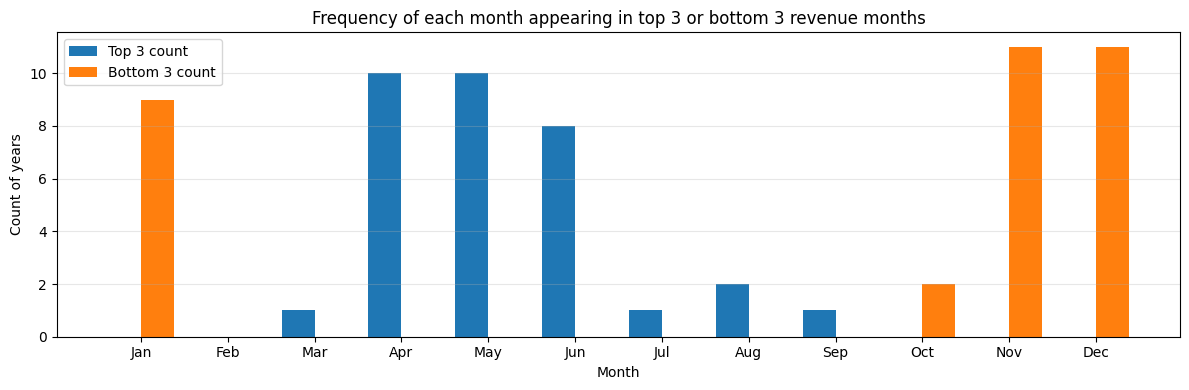

Month rank consistency across years


,month,month_name,years_observed,avg_monthly_revenue,std_monthly_revenue,coef_variation,top_3_count,top_3_frequency_pct,bottom_3_count,bottom_3_frequency_pct,avg_rank,seasonality_flag,stability_flag
0,1,Jan,10,8.032579e+07,2.292510e+07,0.285402,0,0.000000,9,90.000000,10.600000,repeated low-revenue month,more stable
1,2,Feb,10,9.815858e+07,2.326040e+07,0.236968,0,0.000000,0,0.000000,8.200000,mixed/neutral,more stable
2,3,Mar,10,1.527737e+08,2.982642e+07,0.195233,1,10.000000,0,0.000000,4.600000,mixed/neutral,more stable
3,4,Apr,10,1.959886e+08,5.341216e+07,0.272527,10,100.000000,0,0.000000,2.000000,repeated high-revenue month,more stable
4,5,May,10,2.038379e+08,5.825765e+07,0.285804,10,100.000000,0,0.000000,1.500000,repeated high-revenue month,more stable
5,6,Jun,10,1.928133e+08,6.101454e+07,0.316444,8,80.000000,0,0.000000,2.800000,repeated high-revenue month,more volatile
6,7,Jul,11,1.431826e+08,3.932587e+07,0.274655,1,9.090909,0,0.000000,4.818182,mixed/neutral,more stable
7,8,Aug,11,1.376770e+08,4.994808e+07,0.362792,2,18.181818,0,0.000000,5.454545,mixed/neutral,more volatile
8,9,Sep,11,1.139348e+08,2.842642e+07,0.249497,1,9.090909,0,0.000000,6.363636,mixed/neutral,more stable
9,10,Oct,11,1.023845e+08,2.755248e+07,0.269108,0,0.000000,2,18.181818,8.000000,mixed/neutral,more stable


Months frequently in top 3


,month,month_name,years_observed,avg_monthly_revenue,std_monthly_revenue,coef_variation,top_3_count,top_3_frequency_pct,bottom_3_count,bottom_3_frequency_pct,avg_rank,seasonality_flag,stability_flag
3,4,Apr,10,1.959886e+08,5.341216e+07,0.272527,10,100.000000,0,0.0,2.000000,repeated high-revenue month,more stable
4,5,May,10,2.038379e+08,5.825765e+07,0.285804,10,100.000000,0,0.0,1.500000,repeated high-revenue month,more stable
5,6,Jun,10,1.928133e+08,6.101454e+07,0.316444,8,80.000000,0,0.0,2.800000,repeated high-revenue month,more volatile
7,8,Aug,11,1.376770e+08,4.994808e+07,0.362792,2,18.181818,0,0.0,5.454545,mixed/neutral,more volatile
2,3,Mar,10,1.527737e+08,2.982642e+07,0.195233,1,10.000000,0,0.0,4.600000,mixed/neutral,more stable
6,7,Jul,11,1.431826e+08,3.932587e+07,0.274655,1,9.090909,0,0.0,4.818182,mixed/neutral,more stable


Months frequently in bottom 3


,month,month_name,years_observed,avg_monthly_revenue,std_monthly_revenue,coef_variation,top_3_count,top_3_frequency_pct,bottom_3_count,bottom_3_frequency_pct,avg_rank,seasonality_flag,stability_flag
11,12,Dec,11,7.825484e+07,2.734319e+07,0.349412,0,0.0,11,100.000000,10.545455,repeated low-revenue month,more volatile
10,11,Nov,11,7.833885e+07,2.394161e+07,0.305616,0,0.0,11,100.000000,10.636364,repeated low-revenue month,more stable
0,1,Jan,10,8.032579e+07,2.292510e+07,0.285402,0,0.0,9,90.000000,10.600000,repeated low-revenue month,more stable
9,10,Oct,11,1.023845e+08,2.755248e+07,0.269108,0,0.0,2,18.181818,8.000000,mixed/neutral,more stable
3,4,Apr,10,1.959886e+08,5.341216e+07,0.272527,10,100.0,0,0.000000,2.000000,repeated high-revenue month,more stable
2,3,Mar,10,1.527737e+08,2.982642e+07,0.195233,1,10.0,0,0.000000,4.600000,mixed/neutral,more stable


Most volatile months


,month,month_name,years_observed,avg_monthly_revenue,std_monthly_revenue,coef_variation,top_3_count,top_3_frequency_pct,bottom_3_count,bottom_3_frequency_pct,avg_rank,seasonality_flag,stability_flag
7,8,Aug,11,1.376770e+08,4.994808e+07,0.362792,2,18.181818,0,0.0,5.454545,mixed/neutral,more volatile
11,12,Dec,11,7.825484e+07,2.734319e+07,0.349412,0,0.000000,11,100.0,10.545455,repeated low-revenue month,more volatile
5,6,Jun,10,1.928133e+08,6.101454e+07,0.316444,8,80.000000,0,0.0,2.800000,repeated high-revenue month,more volatile
10,11,Nov,11,7.833885e+07,2.394161e+07,0.305616,0,0.000000,11,100.0,10.636364,repeated low-revenue month,more stable
4,5,May,10,2.038379e+08,5.825765e+07,0.285804,10,100.000000,0,0.0,1.500000,repeated high-revenue month,more stable
0,1,Jan,10,8.032579e+07,2.292510e+07,0.285402,0,0.000000,9,90.0,10.600000,repeated low-revenue month,more stable


In [10]:
if daily.empty:
    print("Pattern consistency analysis skipped because daily series is unavailable.")
    pattern_consistency_df = pd.DataFrame()
else:
    month_ranks = monthly_revenue.copy()
    month_ranks["rank_desc"] = month_ranks.groupby("year")["revenue"].rank(ascending=False, method="min")
    month_ranks["rank_asc"] = month_ranks.groupby("year")["revenue"].rank(ascending=True, method="min")
    month_ranks["is_top_3"] = month_ranks["rank_desc"] <= 3
    month_ranks["is_bottom_3"] = month_ranks["rank_asc"] <= 3

    month_stats = month_ranks.groupby("month").agg(
        years_observed=("year", "nunique"),
        avg_monthly_revenue=("revenue", "mean"),
        median_monthly_revenue=("revenue", "median"),
        std_monthly_revenue=("revenue", "std"),
        top_3_count=("is_top_3", "sum"),
        bottom_3_count=("is_bottom_3", "sum"),
        avg_rank=("rank_desc", "mean"),
    ).reset_index()
    month_stats["month_name"] = month_stats["month"].map(dict(enumerate(MONTH_NAMES, start=1)))
    month_stats["coef_variation"] = month_stats["std_monthly_revenue"] / month_stats["avg_monthly_revenue"]
    month_stats["top_3_frequency_pct"] = month_stats["top_3_count"] / month_stats["years_observed"] * 100
    month_stats["bottom_3_frequency_pct"] = month_stats["bottom_3_count"] / month_stats["years_observed"] * 100
    month_stats["seasonality_flag"] = np.select(
        [month_stats["top_3_frequency_pct"] >= 50, month_stats["bottom_3_frequency_pct"] >= 50],
        ["repeated high-revenue month", "repeated low-revenue month"],
        default="mixed/neutral",
    )
    month_stats["stability_flag"] = np.where(month_stats["coef_variation"] >= month_stats["coef_variation"].quantile(0.75), "more volatile", "more stable")
    pattern_consistency_df = month_stats[[
        "month", "month_name", "years_observed", "avg_monthly_revenue", "std_monthly_revenue", "coef_variation",
        "top_3_count", "top_3_frequency_pct", "bottom_3_count", "bottom_3_frequency_pct", "avg_rank", "seasonality_flag", "stability_flag"
    ]]

    top_bottom_frequency_df = pattern_consistency_df[["month", "month_name", "top_3_count", "bottom_3_count"]]
    x = np.arange(len(top_bottom_frequency_df))
    width = 0.38
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(x - width/2, top_bottom_frequency_df["top_3_count"], width, label="Top 3 count")
    ax.bar(x + width/2, top_bottom_frequency_df["bottom_3_count"], width, label="Bottom 3 count")
    ax.set_xticks(x)
    ax.set_xticklabels(top_bottom_frequency_df["month_name"])
    ax.set_title("Frequency of each month appearing in top 3 or bottom 3 revenue months")
    ax.set_xlabel("Month")
    ax.set_ylabel("Count of years")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("Month rank consistency across years")
    display(pattern_consistency_df)
    print("Months frequently in top 3")
    display(pattern_consistency_df.sort_values("top_3_frequency_pct", ascending=False).head(6))
    print("Months frequently in bottom 3")
    display(pattern_consistency_df.sort_values("bottom_3_frequency_pct", ascending=False).head(6))
    print("Most volatile months")
    display(pattern_consistency_df.sort_values("coef_variation", ascending=False).head(6))

## 11. Forecast feature preview

Create a preview of time-based forecast features, including cyclical encodings. `month_sin` and `month_cos` help models understand that December and January are adjacent in the yearly cycle rather than far apart numerically.

In [11]:
if daily.empty:
    print("Forecast feature preview skipped because daily series is unavailable.")
    feature_preview_df = pd.DataFrame()
else:
    feature_table = daily[["date", "revenue"]].copy().sort_values("date").reset_index(drop=True)
    feature_table["year"] = feature_table["date"].dt.year
    feature_table["quarter"] = feature_table["date"].dt.quarter
    feature_table["month"] = feature_table["date"].dt.month
    feature_table["month_name"] = feature_table["date"].dt.month_name().str[:3]
    feature_table["weekofyear"] = feature_table["date"].dt.isocalendar().week.astype(int)
    feature_table["dayofyear"] = feature_table["date"].dt.dayofyear
    feature_table["month_index"] = (feature_table["year"] - feature_table["year"].min()) * 12 + feature_table["month"]
    feature_table["month_sin"] = np.sin(2 * np.pi * feature_table["month"] / 12)
    feature_table["month_cos"] = np.cos(2 * np.pi * feature_table["month"] / 12)
    feature_table["quarter_sin"] = np.sin(2 * np.pi * feature_table["quarter"] / 4)
    feature_table["quarter_cos"] = np.cos(2 * np.pi * feature_table["quarter"] / 4)

    feature_preview_df = pd.concat([feature_table.head(10), feature_table.tail(10)], ignore_index=True)
    display(feature_preview_df)

,date,revenue,year,quarter,month,month_name,weekofyear,dayofyear,month_index,month_sin,month_cos,quarter_sin,quarter_cos
0,2012-07-04,5123547.94,2012,3,7,Jul,27,186,7,-5.000000e-01,-0.866025,-1.000000e+00,-1.836970e-16
1,2012-07-05,2751773.45,2012,3,7,Jul,27,187,7,-5.000000e-01,-0.866025,-1.000000e+00,-1.836970e-16
2,2012-07-06,3054029.42,2012,3,7,Jul,27,188,7,-5.000000e-01,-0.866025,-1.000000e+00,-1.836970e-16
3,2012-07-07,2667930.94,2012,3,7,Jul,27,189,7,-5.000000e-01,-0.866025,-1.000000e+00,-1.836970e-16
4,2012-07-08,2360851.90,2012,3,7,Jul,27,190,7,-5.000000e-01,-0.866025,-1.000000e+00,-1.836970e-16
5,2012-07-09,3548386.46,2012,3,7,Jul,28,191,7,-5.000000e-01,-0.866025,-1.000000e+00,-1.836970e-16
6,2012-07-10,5234938.62,2012,3,7,Jul,28,192,7,-5.000000e-01,-0.866025,-1.000000e+00,-1.836970e-16
7,2012-07-11,5582884.78,2012,3,7,Jul,28,193,7,-5.000000e-01,-0.866025,-1.000000e+00,-1.836970e-16
8,2012-07-12,5734632.02,2012,3,7,Jul,28,194,7,-5.000000e-01,-0.866025,-1.000000e+00,-1.836970e-16
9,2012-07-13,5309511.71,2012,3,7,Jul,28,195,7,-5.000000e-01,-0.866025,-1.000000e+00,-1.836970e-16


## 12. Key observations and warnings

Print a concise summary of peak/low months and quarters, seasonality stability, practical planning implications, and recommended forecast calendar features.

In [12]:
if daily.empty:
    print("No final insight summary because a usable daily revenue series was not available.")
else:
    highest_months = month_summary_df.sort_values("average_daily_revenue", ascending=False).head(3)[["month_name", "average_daily_revenue", "total_revenue"]].to_dict("records")
    lowest_months = month_summary_df.sort_values("average_daily_revenue", ascending=True).head(3)[["month_name", "average_daily_revenue", "total_revenue"]].to_dict("records")
    peak_quarters = quarter_summary_df.sort_values("average_daily_revenue", ascending=False).head(2)[["quarter_label", "average_daily_revenue", "total_revenue"]].to_dict("records")
    low_quarters = quarter_summary_df.sort_values("average_daily_revenue", ascending=True).head(2)[["quarter_label", "average_daily_revenue", "total_revenue"]].to_dict("records")
    repeated_top_months = pattern_consistency_df.sort_values("top_3_frequency_pct", ascending=False).head(4)[["month_name", "top_3_count", "top_3_frequency_pct", "seasonality_flag"]].to_dict("records")
    repeated_low_months = pattern_consistency_df.sort_values("bottom_3_frequency_pct", ascending=False).head(4)[["month_name", "bottom_3_count", "bottom_3_frequency_pct", "seasonality_flag"]].to_dict("records")
    unstable_months = pattern_consistency_df.sort_values("coef_variation", ascending=False).head(4)[["month_name", "coef_variation", "stability_flag"]].to_dict("records")
    stable_or_unstable = "stable enough to model with calendar features" if pattern_consistency_df["top_3_frequency_pct"].max() >= 50 or pattern_consistency_df["bottom_3_frequency_pct"].max() >= 50 else "mixed/unstable across years"
    planning_implications = [
        "Plan higher inventory buffers before repeatedly high-revenue months and peak quarters.",
        "Use low-revenue months as candidates for demand stimulation or conservative inventory planning.",
        "Treat high-volatility months as harder-to-forecast periods and monitor related drivers such as promotions, traffic, stockouts, and returns.",
    ]
    recommended_features = [
        "month and quarter categorical features",
        "month_sin and month_cos cyclical encodings",
        "quarter_sin and quarter_cos cyclical encodings",
        "month_index for long-run progression",
        "year, weekofyear, dayofyear",
        "flags for repeatedly high or low seasonal months after validation",
    ]

    print("Insight summary")
    print("- Highest-revenue months:", highest_months)
    print("- Lowest-revenue months:", lowest_months)
    print("- Peak quarters:", peak_quarters)
    print("- Low quarters:", low_quarters)
    print(f"- Yearly seasonality appears: {stable_or_unstable}.")
    print("- Months repeatedly appearing in top revenue periods:", repeated_top_months)
    print("- Months repeatedly appearing in low revenue periods:", repeated_low_months)
    print("- Months with unstable/high-variance behavior:", unstable_months)
    print("- Practical implications for inventory and marketing:", planning_implications)
    print("- Recommended forecast calendar features:", recommended_features)

Insight summary
- Highest-revenue months: [{'month_name': 'May', 'average_daily_revenue': 6575416.349483871, 'total_revenue': 2038379068.34}, {'month_name': 'Apr', 'average_daily_revenue': 6532951.8821, 'total_revenue': 1959885564.63}, {'month_name': 'Jun', 'average_daily_revenue': 6427108.652266667, 'total_revenue': 1928132595.68}]
- Lowest-revenue months: [{'month_name': 'Dec', 'average_daily_revenue': 2524349.622932551, 'total_revenue': 860803221.42}, {'month_name': 'Jan', 'average_daily_revenue': 2591154.6045483868, 'total_revenue': 803257927.41}, {'month_name': 'Nov', 'average_daily_revenue': 2611295.0148484847, 'total_revenue': 861727354.9}]
- Peak quarters: [{'quarter_label': 'Q2', 'average_daily_revenue': 6512524.427087911, 'total_revenue': 5926397228.65}, {'quarter_label': 'Q3', 'average_daily_revenue': 4304002.217314173, 'total_revenue': 4342738237.27}]
- Low quarters: [{'quarter_label': 'Q4', 'average_daily_revenue': 2814980.1147035575, 'total_revenue': 2848759876.08}, {'qua